# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on stock data.

In [4]:
%pip install python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install python-dotenv --quiet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from utils.config import get_config

%matplotlib inline
sns.set_style('darkgrid')

## Load Data

In [6]:
# Load stock data
ticker = 'AAPL'
data = pd.read_csv(f'../data/raw/{ticker}.csv', index_col=0, parse_dates=True)
data.head()

C:\Users\Nihar\AppData\Local\Temp\ipykernel_20360\1110931256.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(f'../data/raw/{ticker}.csv', index_col=0, parse_dates=True)


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,NaN,NaN,NaN,NaN,NaN
2020-01-02,72.46824645996094,72.52856629098083,71.2232442641189,71.47658460909824,135480400
2020-01-03,71.76372528076172,72.52375386627762,71.53933722124737,71.69616734789946,146322800
2020-01-06,72.33555603027344,72.3741616151194,70.63453932655295,70.88547194642054,118387200


## Basic Statistics

In [7]:
data.describe()

,Close,High,Low,Open,Volume
count,1246,1246,1246,1246,1246
unique,1231,1246,1246,1246,1244
top,142.22662353515625,249.67081089954078,245.15124311202538,246.84360125039836,97918500
freq,2,1,1,1,2


## Price Trends

In [12]:
# Data checks before plotting
print('data type:', type(data))
print('columns:', list(data.columns))
print('index dtype:', data.index.dtype)
print(data.head())
# Ensure 'Close' exists and is numeric
if 'Close' in data.columns:
    data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
    print("'Close' dtype after coercion:", data['Close'].dtype)
    print("'Close' NaNs:", data['Close'].isna().sum())
else:
    print("Column 'Close' not found in data. Available columns:", list(data.columns))
# Ensure 'Volume' exists and is numeric
if 'Volume' in data.columns:
    data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')
    print("'Volume' dtype after coercion:", data['Volume'].dtype)
    print("'Volume' NaNs:", data['Volume'].isna().sum())
else:
    print("Column 'Volume' not found in data. Available columns:", list(data.columns))
# Convert index to datetime if needed
if not np.issubdtype(data.index.dtype, np.datetime64):
    try:
        data.index = pd.to_datetime(data.index)
        print('Converted index to datetime')
    except Exception as e:
        print('Failed to convert index to datetime:', e)
# Drop rows where Close or Volume are NaN to avoid plotting errors
before_rows = len(data)
data = data.dropna(subset=['Close','Volume'])
after_rows = len(data)
print(f'Dropped {before_rows - after_rows} rows with NaN Close/Volume')

data type: <class 'pandas.core.frame.DataFrame'>
columns: ['Close', 'High', 'Low', 'Open', 'Volume']
index dtype: object
                Close               High                Low  \
Price                                                         
Ticker            NaN               AAPL               AAPL   
Date              NaN                NaN                NaN   
2020-01-02  72.468246  72.52856629098083   71.2232442641189   
2020-01-03  71.763725  72.52375386627762  71.53933722124737   
2020-01-06  72.335556   72.3741616151194  70.63453932655295   

                         Open     Volume  
Price                                     
Ticker                   AAPL       AAPL  
Date                      NaN        NaN  
2020-01-02  71.47658460909824  135480400  
2020-01-03  71.69616734789946  146322800  
2020-01-06  70.88547194642054  118387200  
'Close' dtype after coercion: float64
'Close' NaNs: 2
'Volume' dtype after coercion: float64
'Volume' NaNs: 2
Failed to convert index to

C:\Users\Nihar\AppData\Local\Temp\ipykernel_20360\2236103919.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.index = pd.to_datetime(data.index)


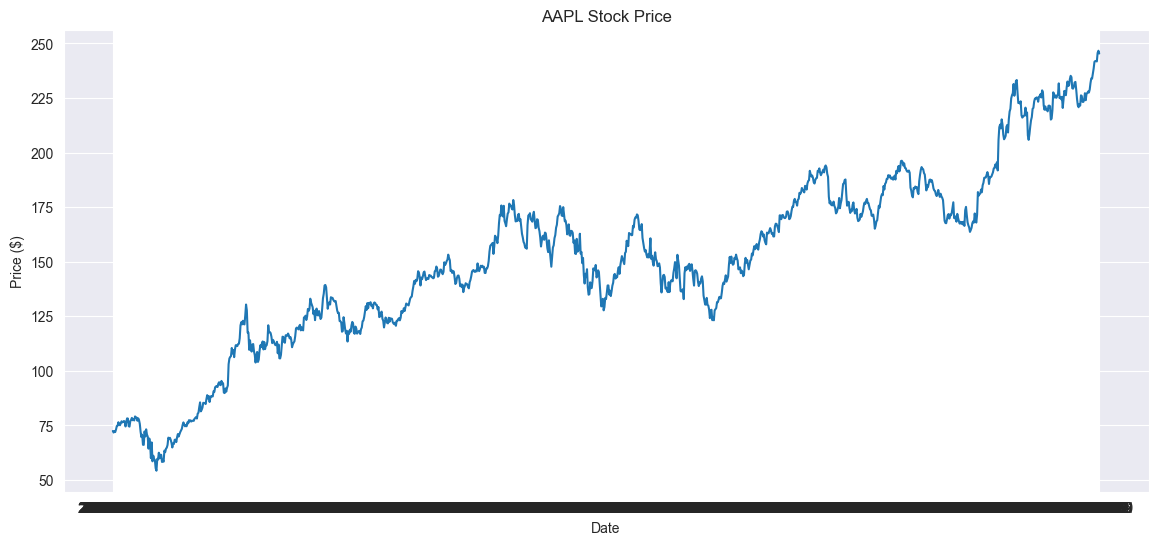

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'])
plt.title(f'{ticker} Stock Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()

## Volume Analysis

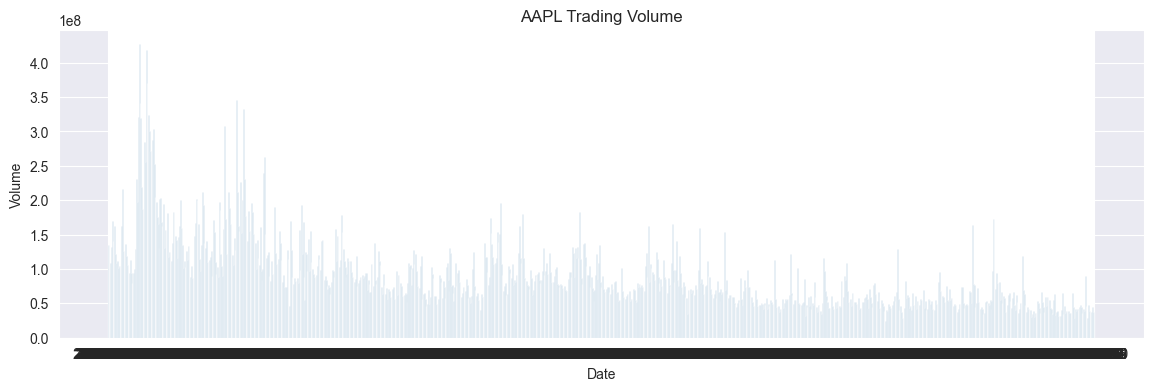

In [14]:
plt.figure(figsize=(14, 4))
plt.bar(data.index, data['Volume'], color='steelblue', alpha=0.5)
plt.title(f'{ticker} Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

## Returns Distribution

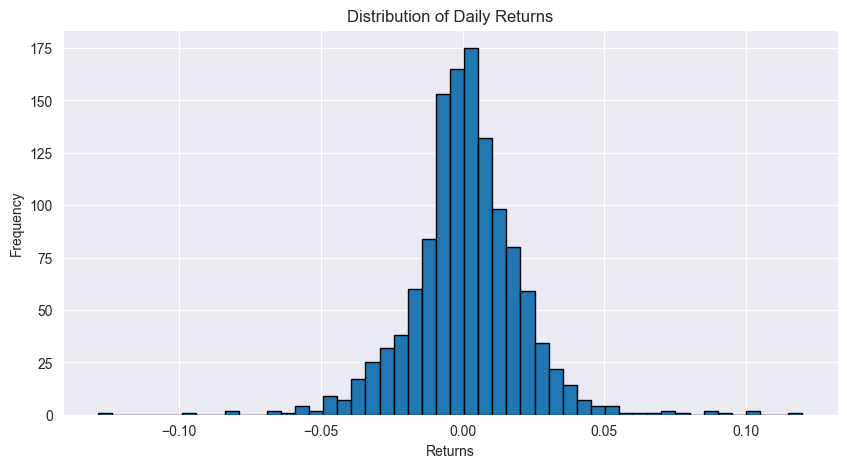

In [15]:
data['returns'] = data['Close'].pct_change()

plt.figure(figsize=(10, 5))
plt.hist(data['returns'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()